<a href="https://colab.research.google.com/github/islenaromero/connectatel-customer-analysis/blob/main/ConnectaTel_Customer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 ConnectaTel Customer Analysis

## Exploratory Data Analysis (EDA)

### Customer Behavior Analysis for a Telecommunications Company in Latin America

---

### 👩‍💻 Author

**Islena Romero**

Telecommunications Engineer | Data Analytics Portfolio

---

### 🛠 Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

---

### 📅 Analysis Period

Historical customer data through **2024**

---

### 🎯 Objective

Analyze customer behavior using service usage, subscription plans, and demographic information to identify consumption patterns, detect unusual behaviors, understand customer churn, and generate business recommendations that support customer retention and service plan optimization.

# 🎯 Business Understanding

## Background

ConnectaTel is a telecommunications company operating in Latin America. The company wants to better understand how customers use its services in order to optimize pricing strategies, improve customer retention, and enhance service offerings.

The available datasets contain customer demographics, subscribed plans, and service usage information recorded through 2024.

---

## Business Questions

This analysis seeks to answer questions such as:

- How do customers use telecommunications services?
- Are current plans aligned with customer consumption?
- Are there customers with unusual usage patterns?
- Which customer groups present different consumption behaviors?
- What business opportunities can be identified through data analysis?

---

## Expected Outcome

Provide data-driven insights that help ConnectaTel:

- Understand customer behavior.
- Improve customer retention.
- Optimize service plans.
- Support strategic business decisions.


# 📚 Import Libraries

The analysis begins by importing the Python libraries required for data manipulation, statistical analysis, and visualization.

### Libraries Used

- **Pandas:** Data manipulation and analysis.
- **NumPy:** Numerical computations.
- **Matplotlib:** Data visualization.

In [1]:
# Data manipulation n visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 📥 Data Loading

Three datasets are used throughout this project:

| Dataset | Description |
|---------|-------------|
| **plans.csv** | Service plans and pricing information. |
| **users_latam.csv** | Customer demographic information and subscription details. |
| **usage.csv** | Customer usage records including minutes and text messages. |

The datasets are loaded into pandas DataFrames to begin the exploratory analysis.

In [3]:
#  Load datasets
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

# 🔍 Dataset Overview

Before starting the analysis, it is important to understand the structure and quality of each dataset.

This step focuses on:

- Number of records
- Available variables
- Data types
- Missing values
- Overall data quality

In [4]:
# Overview
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


# 🔎 Dataset Structure Exploration

Understanding the structure of each dataset is an essential first step before conducting any analysis.

This stage focuses on evaluating the overall characteristics of the data, including the number of observations, available variables, data types, and the completeness of each dataset.

The objective is to identify potential data quality issues early and ensure that the datasets are suitable for further analysis.

### Validation Checklist

- Dataset dimensions (rows and columns)
- Variable names
- Data types
- Non-null values
- Initial data quality assessment

In [11]:
# Dataset dimensions
datasets = {
    "Plans": plans,
    "Users": users,
    "Usage": usage
}

print("📂 Dataset Dimensions\n")

for name, df in datasets.items():
    print(f"{name:<10}: {df.shape[0]} rows × {df.shape[1]} columns")

📂 Dataset Dimensions

Plans     : 2 rows × 8 columns
Users     : 4000 rows × 8 columns
Usage     : 40000 rows × 6 columns


In [8]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


# 🧹 Missing Values Analysis

Missing values can reduce the reliability of an analysis and may require data imputation or record removal.

The objective of this step is to evaluate the completeness of each dataset by identifying the number and proportion of missing values in every column.

This assessment helps determine whether additional data cleaning is necessary before proceeding with the analysis.

In [13]:
# missing values  users and usage
datasets = {
       "Users": users,
    "Usage": usage
}

for name, df in datasets.items():
    print("=" * 70)
    print(f"{name.upper()} DATASET")
    print("=" * 70)

    missing = pd.DataFrame({
        "Missing Values": df.isna().sum(),
        "Percentage (%)": (df.isna().mean() * 100).round(2)
    })

    display(missing)

    print("\n")

USERS DATASET


,Missing Values,Percentage (%)
user_id,0,0.00
first_name,0,0.00
last_name,0,0.00
age,0,0.00
city,469,11.72
reg_date,0,0.00
plan,0,0.00
churn_date,3534,88.35




USAGE DATASET


,Missing Values,Percentage (%)
id,0,0.00
user_id,0,0.00
type,0,0.00
date,50,0.12
duration,22076,55.19
length,17896,44.74


### Interpretation

The missing values analysis revealed different scenarios across the datasets.

- **`churn_date`** contains **88.35%** missing values. This is expected because the field is only populated for customers who have canceled their service. Therefore, the missing values most likely represent **active customers** rather than incomplete data. No imputation is recommended, and the column should either be retained for churn analysis or excluded if it is not required.

- **`date`** contains **50 missing values**, representing only **0.125%** of the dataset. Given the very low proportion of missing records, these observations can be removed without significantly affecting the analysis. Since this variable is essential for time-based analyses, imputing arbitrary dates is not recommended.

- **`duration`** contains **22,076 missing values (55.19%)**. Before deciding whether to remove or impute these values, it is necessary to understand the business meaning of the variable. The missing values may indicate that the field is only applicable to specific types of customer activity, such as phone calls.

- **`length`** contains **17,896 missing values (44.74%)**. Similar to `duration`, the high percentage of missing values suggests that this variable may only be relevant for certain services, such as text messages or mobile data usage. Additional investigation is required before applying any data cleaning strategy.

### Conclusion

The missing values identified in the datasets do not necessarily indicate poor data quality. Instead, several variables appear to contain **structural missing values**, meaning that the absence of information is explained by the business logic rather than by data collection errors.

Understanding the reason behind missing values is essential before deciding whether to remove, retain, or impute them. Consequently, no imputation will be performed at this stage until the context of each variable is fully understood.

# 🔎 Detection of Invalid Values and Sentinel Values

Before performing the exploratory analysis, it is important to verify whether the datasets contain invalid or sentinel values.

Sentinel values are placeholders used to represent missing or unknown information (for example: `-1`, `999`, `"Unknown"`, or empty strings). These values can distort statistical summaries and visualizations if they are not identified and handled appropriately.

This stage evaluates both numerical and categorical variables to detect potential inconsistencies that may require additional data cleaning.

In [14]:
# Numerical summary

print("="*70)
print("USERS DATASET")
print("="*70)
display(users.describe())

print("="*70)
print("USAGE DATASET")
print("="*70)
display(usage.describe())

USERS DATASET


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


USAGE DATASET


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


### Interpretation

#### Users Dataset

- The **`user_id`** column contains unique customer identifiers ranging approximately from **10,000 to 12,999**. Since this variable is an identifier, it should not be treated as a numerical variable for statistical analysis.

- The **`age`** column includes **negative values**, which are not valid for customer ages. These records likely represent data entry errors or invalid values and should be investigated before continuing the analysis. The maximum observed age is **79 years**, which falls within a realistic range.

#### Usage Dataset

- The **`id`** and **`user_id`** columns are unique identifiers rather than analytical variables. Their numerical values do not carry quantitative meaning and should be excluded from statistical analyses.

- The **`duration`** variable ranges from **0 to 120 minutes**, with an average of **5.20 minutes**. The maximum value (120) is considerably higher than the 75th percentile (6.99), suggesting the presence of potential outliers that should be examined during the outlier analysis.

- The **`length`** variable ranges from **0 to 1,490 units**, with an average value of **52.13**. Since the maximum value is substantially higher than the 75th percentile (64), this variable also appears to contain potential outliers that require further investigation.
### Conclusion

The review of numerical variables identified two important findings:

1. The **`age`** variable contains invalid negative values that must be addressed during the data cleaning process.

2. The **`duration`** and **`length`** variables exhibit unusually large maximum values compared to their upper quartiles. These observations may represent legitimate high-usage customers or statistical outliers, and they will be evaluated in detail during the outlier detection stage.

No evidence of invalid identifier values was found, and identifier columns will be excluded from subsequent statistical analyses.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
        print(f"\nColumna: {col}")
        print(users[col].value_counts(dropna=False))
        print("Valores únicos:", users[col].nunique(dropna=True))


Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Valores únicos: 7

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64
Valores únicos: 2


In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` solo tiene dos categorias consitentes


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- city: Tiene valores NaN y  "?", reemplazar "?" por NaN y luego decidir si imputar como "Unknown" o dejar como nulo para análisis posterior.
age:Tiene el valor -999, que es inválido para una edad. reemplazar -999 por NaN y luego imputar con la mediana o eliminar esos registros, según cuántos casos sean.
churn_date: Tiene muchos valores NaN, requiere revision; pueden indicar usuarios activos que no han cancelado. Mantener los nulos o crear una columna auxiliar como is_churned para indicar si el usuario canceló o no.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date']  = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves. En reg_date, la mayoría de los registros están entre 2022 y 2024, pero aparecen 40 registros con año 2026. Como los datos solo llegan hasta 2024, esas fechas son imposibles o futuras y deben revisarse/corregirse; una opción es marcarlas como NaT para no usarlas en el análisis.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas. los registros son del 2024 aunque tiene 50 registros NaN

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- para users tenemos 40 registros invalidos que son los del 2026, una opción es marcarlas como NaT para no usarlas en el análisis
- para usage se presentan 50 fechas faltantes o inválidas NaN. validar si la fecha es necesaria para el análisis temporal, eliminarlos o dejarlos como NaT si no afectan el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(usage['type'], usage['duration'].isna())

duration,False,True
type,,
call,17908,0
text,16,22076


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(usage['type'], usage['length'].isna())

length,False,True
type,,
call,12,17896
text,22092,0


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los nulos en duration dependen claramente de la columna type. En los registros tipo call, duration está completo en 17,908 casos y no tiene nulos; en cambio, en los registros tipo text, duration es nulo en 22,076 casos y solo aparece en 16 casos. Esto indica que duration aplica principalmente a llamadas.

Los nulos en length también dependen claramente de la columna type. En los registros tipo text, length está completo en 22,092 casos y no tiene nulos; en cambio, en los registros tipo call, length es nulo en 17,896 casos y solo aparece en 12 casos. Esto indica que length aplica principalmente a textos.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
(user_profile.describe())

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
(user_profile["plan"].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

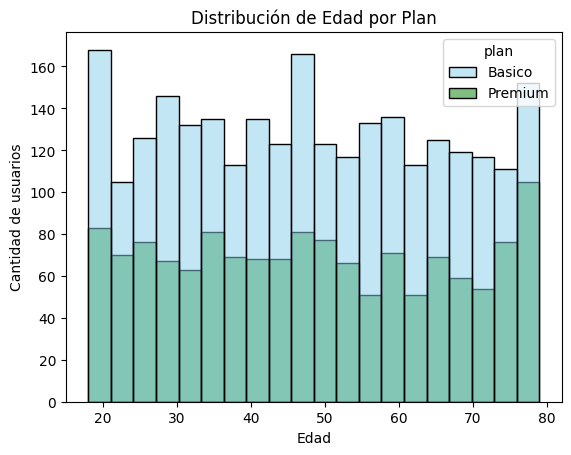

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)
plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- Distribución de Edad por Plan:
La edad se distribuye de forma bastante uniforme entre los usuarios de ambos planes. No hay un patrón donde el plan concentre usuarios mucho más jóvenes o mayores. En general, el plan Básico tiene más usuarios que Premium en casi todos los rangos de edad. La distribución parece relativamente uniforme, no se observa sesgo.


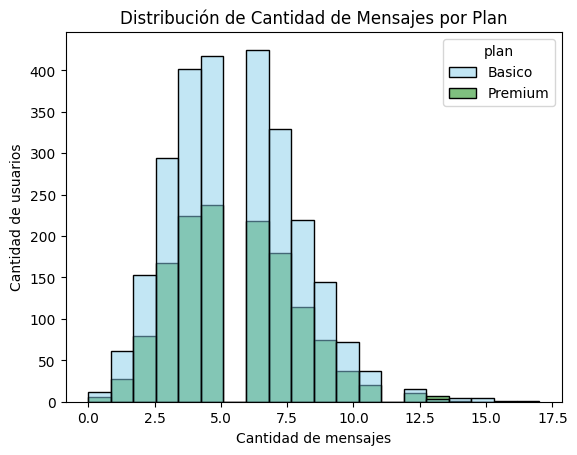

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)
plt.title("Distribución de Cantidad de Mensajes por Plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- Distribución de Cantidad de Mensajes por Plan:
La mayoría de usuarios envía entre 3 y 8 mensajes. Tanto en Básico como en Premium el comportamiento es parecido, aunque Básico tiene mayor cantidad de usuarios en casi todos los rangos. La distribución está ligeramente sesgada a la derecha, con posibles outliers.


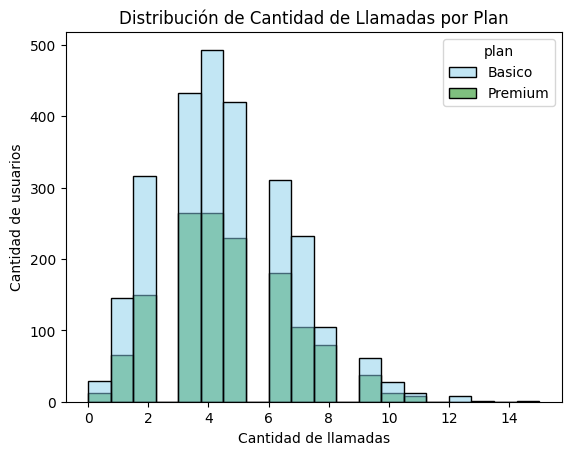

In [ ]:
# Histograma para visualizar la cant_llamadas
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)
plt.title("Distribución de Cantidad de Llamadas por Plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- Distribución de Cantidad de Llamadas por Plan:
No hay una diferencia fuerte entre planes en la forma de la distribución; Básico aparece con más usuarios porque es el plan más frecuente. La distribución está sesgada a la derecha, ya que hay pocos usuarios con muchas llamadas.


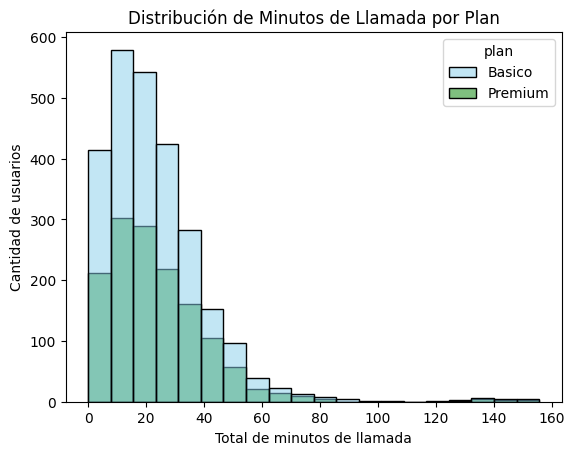

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)
plt.title("Distribución de Minutos de Llamada por Plan")
plt.xlabel("Total de minutos de llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights:
- Distribución de Minutos de Llamada por Plan:
La mayoría de usuarios acumula pocos minutos de llamada, principalmente entre 0 y 40 minutos. Existen algunos usuarios con valores muy altos, especialmente por encima de 100 minutos, lo que sugiere posibles outliers. La distribución está claramente sesgada a la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

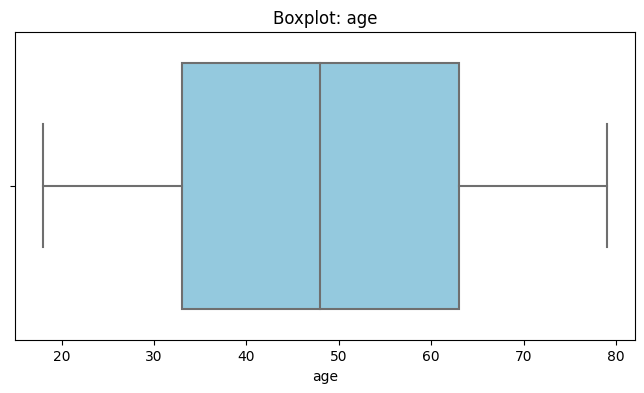

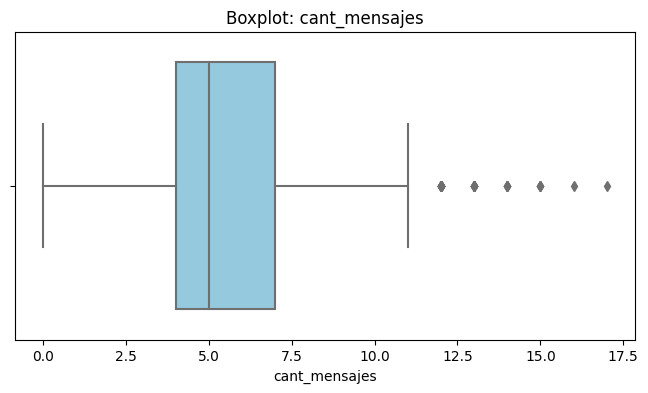

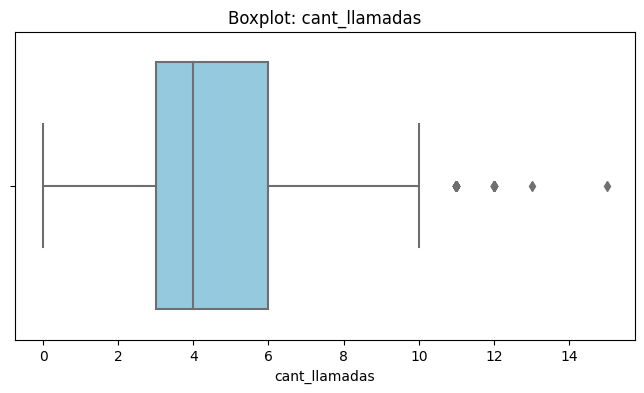

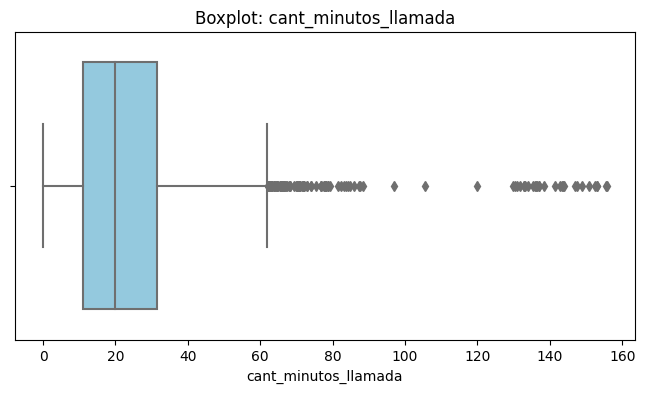

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: En age no se observan outliers relevantes (tener en cuenta que se corrigio el valor -999).
- cant_mensajes: se observan posibles ouliers, algunos valores altos, pero no parecen extremos graves
- cant_llamadas: aparecer valores altos aislados.
- cant_minutos_llamada: sí se observan outliers claros hacia la derecha, ya que algunos usuarios acumulan muchos más minutos que la mayoría.

In [ ]:
# Calcular límites con el método IQR
columnas_limites =['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    outliers_superiores = user_profile[user_profile[col] > limite_superior]

In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener outliers, porque representan usuarios con un volumen alto de mensajes y pueden ser clientes intensivos reales. No parecen errores evidentes, sino comportamientos extremos pero posibles.
- cant_llamadas: mantener o no outliers, porqué? Mantener outliers, porque algunos usuarios pueden realizar muchas llamadas en el periodo analizado. Eliminarlos podría ocultar patrones importantes de uso alto.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener outliers, pero los revisaría con más cuidado, porque los minutos tienen valores más extremos y pueden afectar mucho el promedio. Si no hay evidencia de error, conviene conservarlos y usar métricas como mediana o percentiles.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

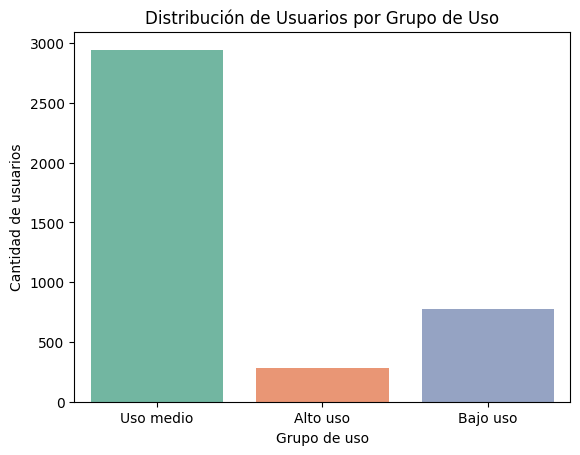

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette='Set2'
)

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

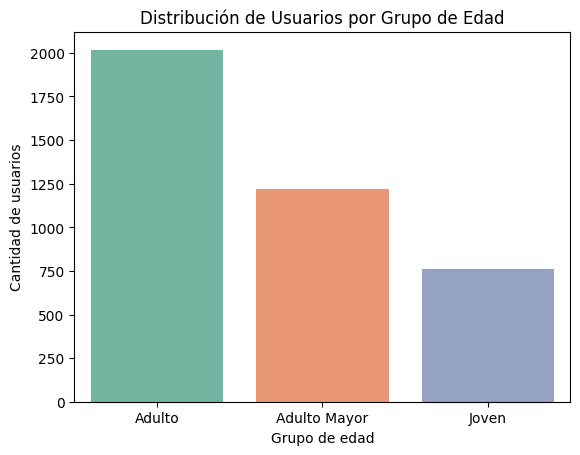

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette='Set2'
)

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Los datos tenían varios problemas de calidad. En users, la columna city tenía 469 valores nulos, equivalentes al 11.7%, además de 96 valores con "?", que se trataron como datos inválidos. La columna churn_date tenía 3534 nulos, equivalentes al 88.35%, aunque estos probablemente representan usuarios activos. También se detectó el valor -999 en age, que fue corregido usando la mediana. En reg_date aparecieron 40 fechas futuras en 2026, aunque el dataset solo debía llegar hasta 2024, por lo que fueron marcadas como nulas. En usage, date tenía 50 valores nulos, equivalentes al 0.125%. Las columnas duration y length tenían muchos nulos, pero dependían del tipo de uso: duration aplica principalmente a llamadas y length a mensajes, por lo que se dejaron como nulos.


🔍 **Segmentos por Edad**
Se identificaron segmentos por edad, los usuarios se clasificaron como Joven, Adulto y Adulto Mayor.  


📊 **Segmentos por Nivel de Uso**
Adicional se identifican segmentos por uso, se clasificaron como Bajo uso, Uso medio y Alto uso según la cantidad de llamadas y mensajes.


➡️ En general, los usuarios Básico y Premium muestran distribuciones similares, aunque el plan Básico concentra más usuarios porque es el plan con mayor presencia en la base.
Los segmentos más valiosos para ConnectaTel parecen ser los usuarios de Uso medio y Alto uso, especialmente si están en Premium o si tienen un alto volumen de llamadas y mensajes. Estos clientes generan mayor actividad en la red y pueden representar mayor potencial de ingresos, retención y venta de servicios adicionales.

Se encontraron outliers en mensajes, llamadas y especialmente en minutos de llamada. Estos valores extremos parecen representar usuarios intensivos reales, no errores evidentes. Para el negocio, esto implica que existe un grupo pequeño de clientes con consumo muy alto que puede afectar los promedios o mejor visto como una oportunidad comercial importante.


💡 **Recomendaciones**
ConnectaTel podría crear ofertas diferenciadas por comportamiento: planes básicos para Bajo uso, beneficios o paquetes flexibles para Uso medio, y planes Premium o ilimitados para Alto uso. También sería útil diseñar campañas de upgrade para usuarios Básico con alto consumo, porque podrían estar dispuestos a pagar más por mejores beneficios. Finalmente, se recomienda monitorear a los usuarios con uso extremo para evitar problemas de saturación, mejorar la experiencia y ofrecer planes personalizados tambien seria bueno validar si son revendedores o si representa algun tipo de fraude, tener en cuenta usuarios de entros penitenciarios como ejemplo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`